<a href="https://colab.research.google.com/github/coinblum01-wq/trucweb/blob/main/NguyenTrongTruc_2474802016707_Lab4" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phần kiến thức cần nhớ**

In [4]:
#KHỞI TẠO VÀ ĐỌC DỮ LIỆU
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('titanic_disaster.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# 1. DATA CLEANSING (LÀM SẠCH DỮ LIỆU)
df.isnull().sum()
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


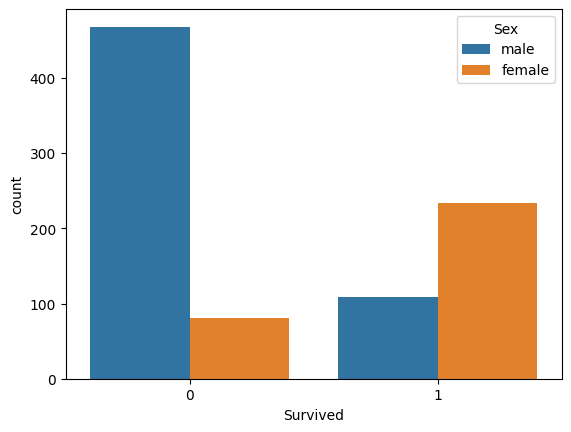

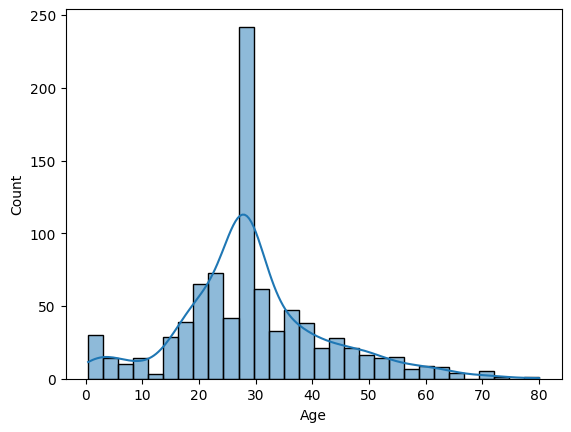

In [7]:
#2. EXPLORATION DATA ANALYSIS (EDA)
df.info()
df.describe()
sns.countplot(data=df, x='Survived', hue='Sex')
plt.show()

sns.histplot(data=df, x='Age', kde=True)
plt.show()

In [3]:
# 3. KỸ THUẬT FUNCTION CHAIN TRONG PANDAS - pipe()
def clean_names(dataframe):
    dataframe['Name'] = dataframe['Name'].str.strip()
    return dataframe

def optimize_types(dataframe):
    dataframe['Pclass'] = dataframe['Pclass'].astype('category')
    dataframe['Sex'] = dataframe['Sex'].astype('category')
    return dataframe

df = (df.pipe(clean_names)
        .pipe(optimize_types))
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
# 4. FEATURE ENGINEERING
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Gom
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

In [12]:
#5. Data Wrangling
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,22.0,1,0,7.2500,2,0,True,False,True,False,True,False,False
1,1,1,38.0,1,0,71.2833,2,0,False,False,False,False,False,True,False
2,1,3,26.0,0,0,7.9250,1,1,False,False,True,True,False,False,False
3,1,1,35.0,1,0,53.1000,2,0,False,False,True,False,False,True,False
4,0,3,35.0,0,0,8.0500,1,1,True,False,True,False,True,False,False


# **PHẦN 1: DATA CLEANSING & FEATURE ENGINEERING**

In [15]:
#1: Viết hàm load_data()
import pandas as pd

def load_data(file_path):
    dataframe = pd.read_csv(file_path)
    return dataframe

df = load_data('titanic_disaster.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


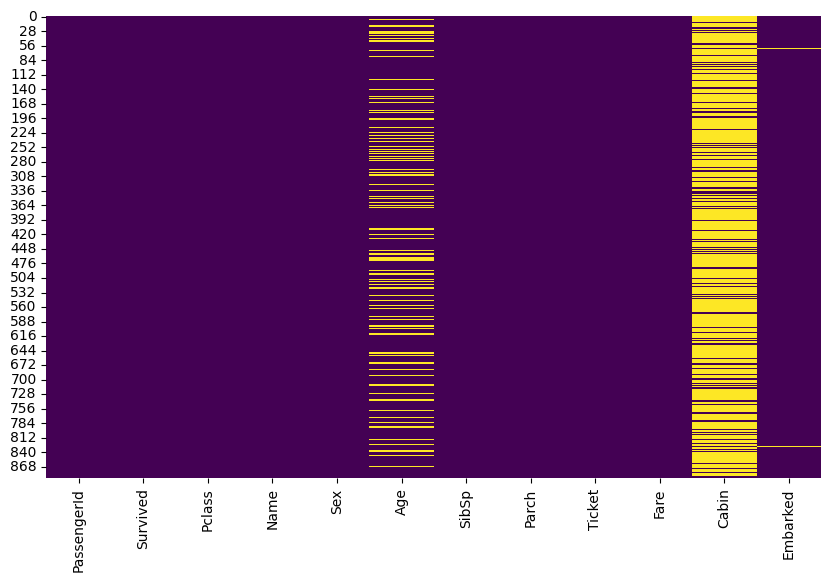

In [16]:
#2: Thống kê dữ liệu thiếu và vẽ Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

print(df.isnull().sum())

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

In [17]:
#3: Tách cột Name thành firstName, secondName và xóa cột Name cũ
df[['secondName', 'firstName']] = df['Name'].str.split(',', n=1, expand=True)
df['firstName'] = df['firstName'].str.strip()
df['secondName'] = df['secondName'].str.strip()
df = df.drop(columns=['Name'])

df.head(10)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,secondName,firstName
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr. Owen Harris
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss. Laina
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr. William Henry
5,6,0,3,male,NaN,0,0,330877,8.4583,NaN,Q,Moran,Mr. James
6,7,0,1,male,54.0,0,0,17463,51.8625,E46,S,McCarthy,Mr. Timothy J
7,8,0,3,male,2.0,3,1,349909,21.0750,NaN,S,Palsson,Master. Gosta Leonard
8,9,1,3,female,27.0,0,2,347742,11.1333,NaN,S,Johnson,Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9,10,1,2,female,14.0,1,0,237736,30.0708,NaN,C,Nasser,Mrs. Nicholas (Adele Achem)


In [18]:
# 4: Xử lý rút gọn kích thước dữ liệu trên cột Sex (male -> M, female -> F)
df['Sex'] = df['Sex'].replace({'male': 'M', 'female': 'F'})
df.head(10)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,secondName,firstName
0,1,0,3,M,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr. Owen Harris
1,2,1,1,F,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,3,1,3,F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss. Laina
3,4,1,1,F,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,5,0,3,M,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr. William Henry
5,6,0,3,M,NaN,0,0,330877,8.4583,NaN,Q,Moran,Mr. James
6,7,0,1,M,54.0,0,0,17463,51.8625,E46,S,McCarthy,Mr. Timothy J
7,8,0,3,M,2.0,3,1,349909,21.0750,NaN,S,Palsson,Master. Gosta Leonard
8,9,1,3,F,27.0,0,2,347742,11.1333,NaN,S,Johnson,Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9,10,1,2,F,14.0,1,0,237736,30.0708,NaN,C,Nasser,Mrs. Nicholas (Adele Achem)


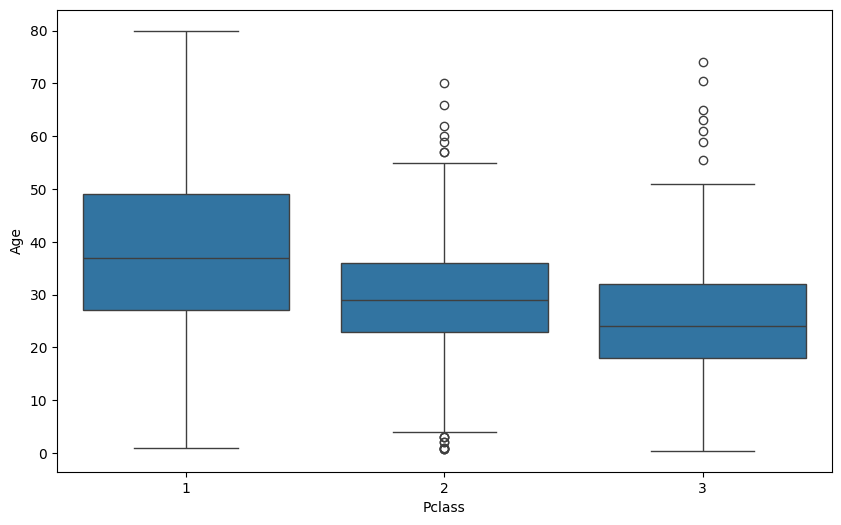

In [19]:
# 5a: Sử dụng Seaborn vẽ Box plot phân phối tuổi theo từng hạng hành khách
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Pclass', y='Age')
plt.show()

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
secondName       0
firstName        0
dtype: int64


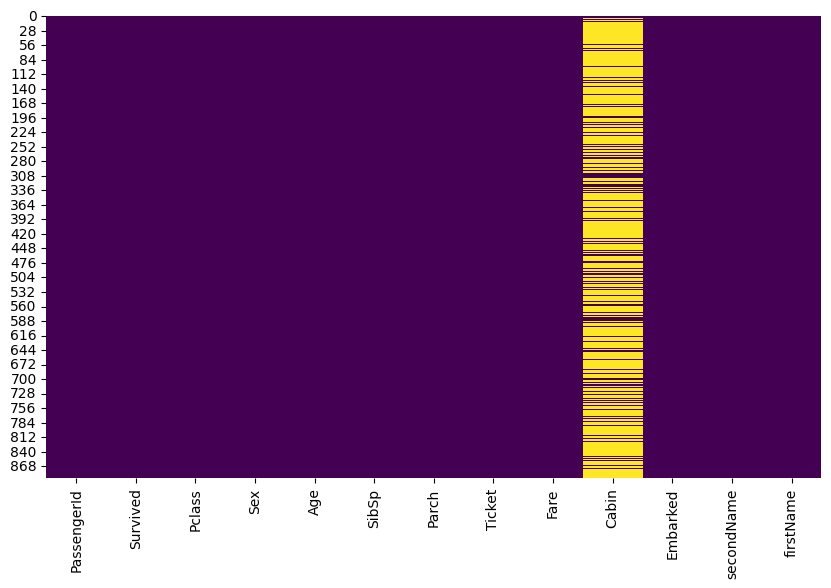

In [20]:
# 5b: Tiến hành thay thế giá trị Age bị thiếu và trực quan bằng Heatmap
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.mean()))
print(df.isnull().sum())

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

In [21]:
# 6: Xây dựng biến số Agegroup có thang đo thứ tự dựa trên độ tuổi
bins = [-1, 12, 18, 60, float('inf')]
labels = ['Kid', 'Teen', 'Adult', 'Older']

df['Agegroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
df['Agegroup'] = pd.Categorical(df['Agegroup'], categories=labels, ordered=True)

df[['Age', 'Agegroup']].head(10)

,Age,Agegroup
0,22.00000,Adult
1,38.00000,Adult
2,26.00000,Adult
3,35.00000,Adult
4,35.00000,Adult
5,25.14062,Adult
6,54.00000,Adult
7,2.00000,Kid
8,27.00000,Adult
9,14.00000,Teen


In [22]:
# 7: Tiến hành thêm đặc trưng về danh xưng (namePrefix) từ cột firstName
df['namePrefix'] = df['firstName'].str.extract(r'([A-Za-z]+)\.', expand=False)
df[['firstName', 'secondName', 'namePrefix']].head(10)

,firstName,secondName,namePrefix
0,Mr. Owen Harris,Braund,Mr
1,Mrs. John Bradley (Florence Briggs Thayer),Cumings,Mrs
2,Miss. Laina,Heikkinen,Miss
3,Mrs. Jacques Heath (Lily May Peel),Futrelle,Mrs
4,Mr. William Henry,Allen,Mr
5,Mr. James,Moran,Mr
6,Mr. Timothy J,McCarthy,Mr
7,Master. Gosta Leonard,Palsson,Master
8,Mrs. Oscar W (Elisabeth Vilhelmina Berg),Johnson,Mrs
9,Mrs. Nicholas (Adele Achem),Nasser,Mrs


In [23]:
# 8: Khai thác thông tin số lượng thành viene đi theo nhóm (familySize)
df['familySize'] = 1 + df['SibSp'] + df['Parch']
df[['SibSp', 'Parch', 'familySize']].head(10)

,SibSp,Parch,familySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


In [25]:
# 9: Tạo thêm đặc trưng ‘Alone’ để xác định hành khách đi theo nhóm hay cá nhân
import numpy as np

df['Alone'] = np.where(df['familySize'] <= 1, 1, 0)
df[['familySize', 'Alone']].head(10)

,familySize,Alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


In [26]:
# 10: Tiến hành tách loại cabin (typeCabin) và xử lý dữ liệu thiếu bằng "Unknown"
df['Cabin'] = df['Cabin'].fillna('Unknown')
df['typeCabin'] = df['Cabin'].astype(str).str[0]

df[['Cabin', 'typeCabin']].head(10)

,Cabin,typeCabin
0,Unknown,U
1,C85,C
2,Unknown,U
3,C123,C
4,Unknown,U
5,Unknown,U
6,E46,E
7,Unknown,U
8,Unknown,U
9,Unknown,U


In [34]:
# 11: Loại bỏ dữ liệu trùng lặp giữa hai tập train và test, ưu tiên giữ lại tập train
df = df.sort_values(by='Survived', na_position='last')
df = df.drop_duplicates(subset=['PassengerId'], keep='first')
print(f"Số lượng dòng còn lại trong DataFrame: {len(df)}")

Số lượng dòng còn lại trong DataFrame: 891


# **PHẦN 2: KHAI THÁC THÔNG TIN HỮU ÍCH – EDA**

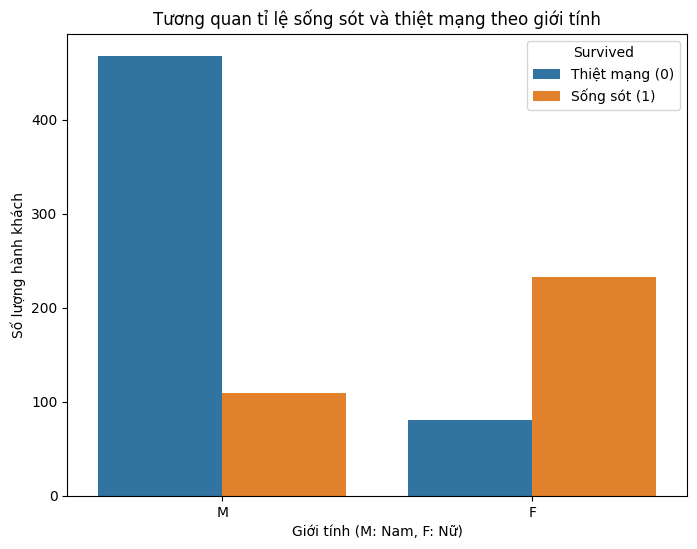

In [35]:
# 12: Trực quan thông tin tương quan tỉ lệ sống sót và thiệt mạng trên từng nhóm giới tính
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Tương quan tỉ lệ sống sót và thiệt mạng theo giới tính')
plt.xlabel('Giới tính (M: Nam, F: Nữ)')
plt.ylabel('Số lượng hành khách')
plt.legend(title='Survived', labels=['Thiệt mạng (0)', 'Sống sót (1)'])
plt.show()

Nhận xét:
Biểu đồ trực quan cho thấy sự chênh lệch vô cùng lớn về tỷ lệ sống sót giữa hai nhóm giới tính:

Nhóm Nữ giới (F): Số lượng người sống sót vượt trội hoàn toàn so với số người thiệt mạng. Phần lớn hành khách nữ trên tàu đều được cứu sống.

Nhóm Nam giới (M): Tình thế hoàn toàn ngược lại khi số lượng nam giới thiệt mạng chiếm tỷ lệ áp đảo, trong khi số người sống sót chỉ chiếm một phần rất nhỏ.

Thông tin giá trị: Giới tính là một đặc trưng cực kỳ quan trọng ảnh hưởng trực tiếp đến khả năng sống sót. Điều này phản ánh đúng quy tắc cứu hộ thực tế trên tàu Titanic: "Phụ nữ và trẻ em được ưu tiên trước".

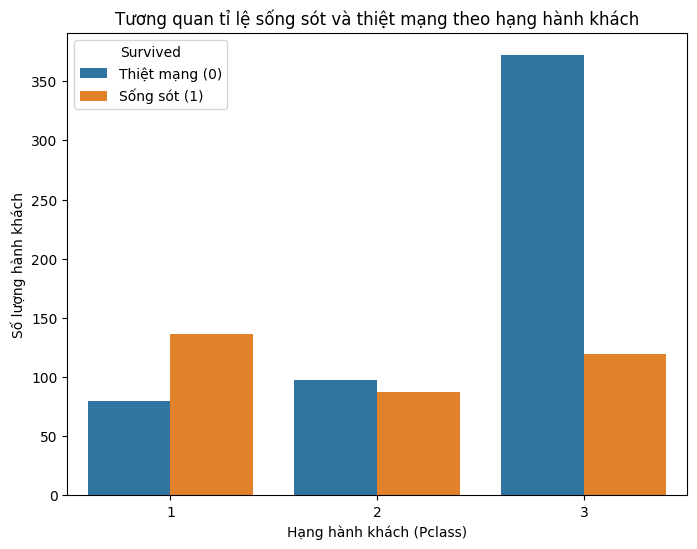

In [36]:
# 13: Trực quan thông tin hành khách sống sót trên từng nhóm phân loại hành khách (Pclass)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Tương quan tỉ lệ sống sót và thiệt mạng theo hạng hành khách')
plt.xlabel('Hạng hành khách (Pclass)')
plt.ylabel('Số lượng hành khách')
plt.legend(title='Survived', labels=['Thiệt mạng (0)', 'Sống sót (1)'])
plt.show()

Nhận xét:
Biểu đồ trực quan cho thấy sự phân hóa rõ rệt về khả năng sống sót dựa trên hạng vé của hành khách:

Hạng 1 (Pclass 1): Đây là nhóm duy nhất có số lượng người sống sót cao hơn hẳn số lượng người thiệt mạng. Tỷ lệ cứu hộ ở hạng vé cao cấp này là tốt nhất.

Hạng 2 (Pclass 2): Tỷ lệ sống sót và thiệt mạng ở mức khá cân bằng nhau, cơ hội sống sót rơi vào khoảng 50-50.

Hạng 3 (Pclass 3): Số lượng hành khách thiệt mạng cao một cách khủng khiếp và chiếm tỷ lệ áp đảo hoàn toàn so với số người may mắn sống sót.

Thông tin giá trị: Hạng hành khách (Pclass) tỷ lệ thuận với cơ hội sống sót. Địa vị xã hội hoặc vị trí cabin (thường các cabin hạng 3 nằm sâu dưới đáy tàu) đóng vai trò quyết định lớn đến việc tiếp cận các xuồng cứu sinh khi thảm họa xảy ra.

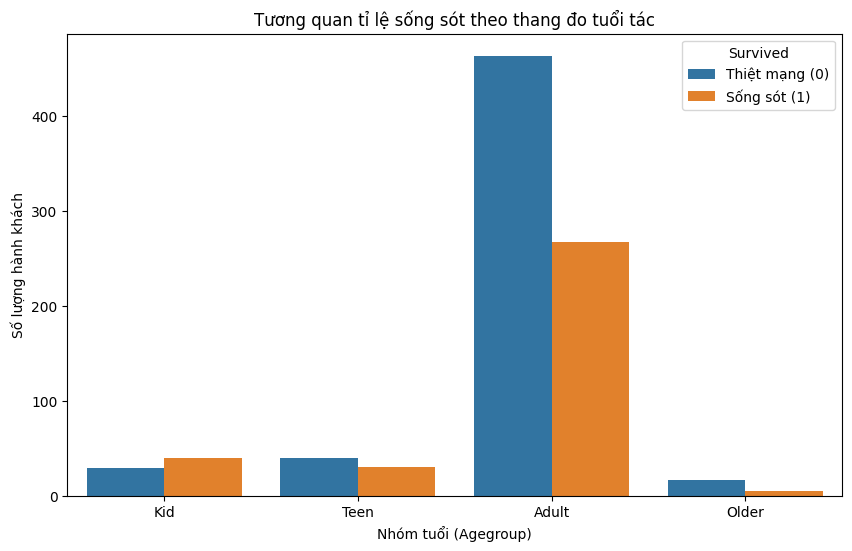

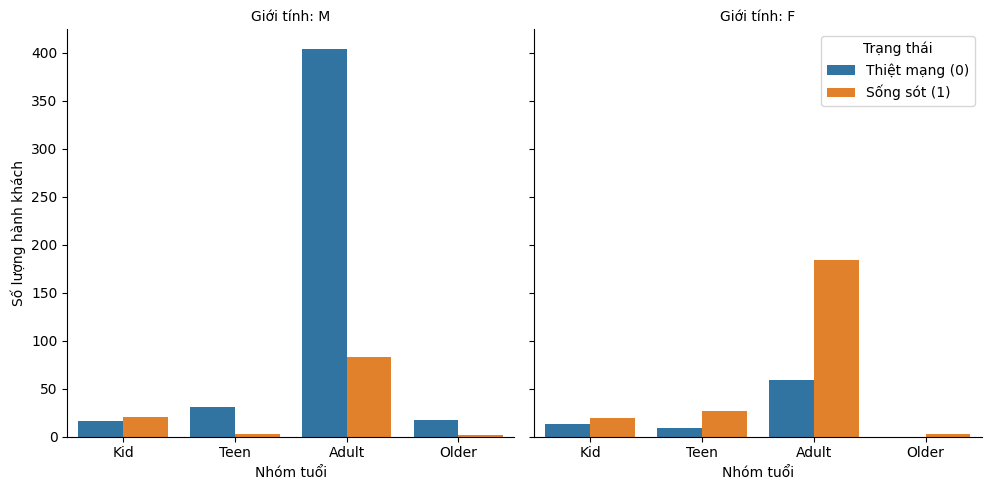

In [44]:
# 14: Trực quan thông tin hành khách sống sót trên từng nhóm giới tính và thang đo tuổi tác
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Agegroup', hue='Survived')
plt.title('Tương quan tỉ lệ sống sót theo thang đo tuổi tác')
plt.xlabel('Nhóm tuổi (Agegroup)')
plt.ylabel('Số lượng hành khách')
plt.legend(title='Survived', labels=['Thiệt mạng (0)', 'Sống sót (1)'])
plt.show()

# Trực quan chi tiết kết hợp cả nhóm tuổi và giới tính bằng Catplot (Đã sửa lỗi cảnh báo)
g = sns.catplot(
    data=df,
    x='Agegroup',
    hue='Survived',
    col='Sex',
    kind='count',
    height=5,
    aspect=1,
    legend=False
)
g.set_axis_labels("Nhóm tuổi", "Số lượng hành khách")
g.set_titles("Giới tính: {col_name}")

# Thêm duy nhất một bảng chú thích chuẩn cho biểu đồ catplot
plt.legend(title='Trạng thái', labels=['Thiệt mạng (0)', 'Sống sót (1)'], loc='upper right')
plt.show()

Nhận xét:
Biểu đồ trực quan kết hợp đa biến giữa nhóm tuổi (Agegroup) và giới tính (Sex) mang lại những phát hiện rất sâu sắc:

Nhóm trẻ em (Kid): Đây là nhóm có tỷ lệ sống sót rất cao ở cả hai giới tính nam và nữ. Điều này chứng minh quy định nhường lối cho trẻ em được thực thi rất nghiêm ngặt.

Nhóm người trưởng thành (Adult): Sự phân hóa giới tính thể hiện rõ rệt nhất ở nhóm này. Trong khi phụ nữ trưởng thành có tỷ lệ sống sót cao áp đảo, thì đàn ông trưởng thành lại là nhóm có số lượng thiệt mạng đông nhất trên tàu.

Nhóm người già (Older): Tỷ lệ sống sót ở nhóm này khá thấp, đặc biệt là ở nam giới lớn tuổi, do hạn chế về mặt thể lực trong tình huống chen lấn cứu hộ khẩn cấp.

Thông tin giá trị: Cơ hội sống sót của một hành khách phụ thuộc vào sự ưu tiên kết hợp: Ưu tiên giới tính trước, sau đó đến ưu tiên độ tuổi. Đàn ông trưởng thành và người già là những đối tượng chịu thiệt thòi lớn nhất trong công tác cứu nạn.

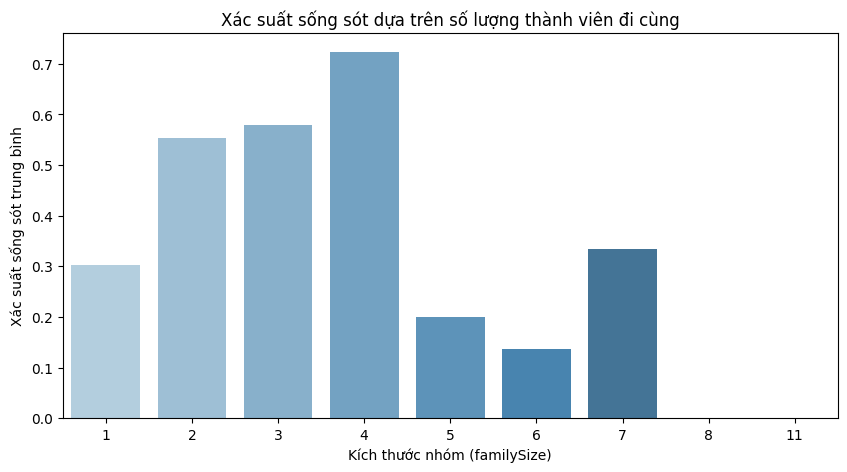

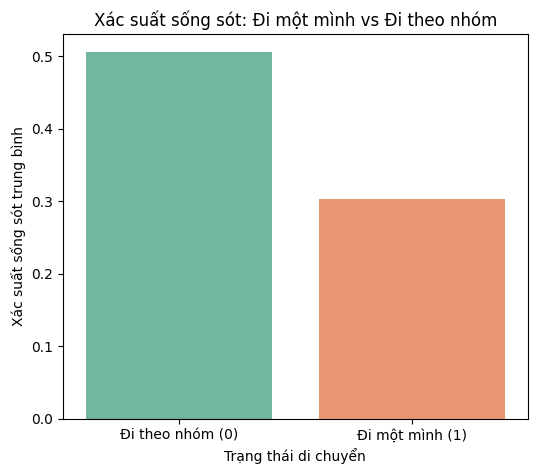

In [43]:
# 15: Trực quan xác suất hành khách sống sót dựa trên thông tin nhóm đi cùng (familySize và Alone)
import matplotlib.pyplot as plt
import seaborn as sns

# Biểu đồ 1: Xác suất sống sót dựa trên kích thước nhóm (familySize)
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='familySize', y='Survived', hue='familySize', errorbar=None, palette='Blues_d', legend=False)
plt.title('Xác suất sống sót dựa trên số lượng thành viên đi cùng')
plt.xlabel('Kích thước nhóm (familySize)')
plt.ylabel('Xác suất sống sót trung bình')
plt.show()

# Biểu đồ 2: Xác suất sống sót giữa người đi một mình (Alone=1) và đi theo nhóm (Alone=0)
plt.figure(figsize=(6, 5))
sns.barplot(data=df, x='Alone', y='Survived', hue='Alone', errorbar=None, palette='Set2', legend=False)
plt.title('Xác suất sống sót: Đi một mình vs Đi theo nhóm')
plt.xticks([0, 1], ['Đi theo nhóm (0)', 'Đi một mình (1)'])
plt.xlabel('Trạng thái di chuyển')
plt.ylabel('Xác suất sống sót trung bình')
plt.show()

Nhận xét:
Biểu đồ trực quan hóa mối quan hệ giữa đặc trưng nhóm đi cùng (familySize, Alone) và xác suất sống sót mang lại những thông tin giá trị sau:

Kích thước nhóm lý tưởng (familySize từ 2 đến 4): Những hành khách đi cùng gia đình hoặc nhóm nhỏ từ 2 đến 4 người có xác suất sống sót cao nhất (đỉnh điểm là nhóm 3-4 người). Việc đi theo nhóm vừa phải giúp các thành viên dễ dàng hỗ trợ, tìm kiếm và bảo vệ nhau trong lúc hỗn loạn, đồng thời không quá cồng kềnh khi di chuyển lên xuồng cứu sinh.

Kích thước nhóm quá lớn (familySize >= 5): Khi số lượng thành viên trong nhóm quá đông, xác suất sống sót giảm mạnh một cách rõ rệt. Việc tìm kiếm đầy đủ người thân trong đám đông hỗn loạn hoặc cố gắng để cả gia đình lớn cùng lên một xuồng cứu hộ là cực kỳ khó khăn, dẫn đến hậu quả bị kẹt lại.

Đi một mình (Alone = 1): Hành khách đi một mình có xác suất sống sót thấp hơn đáng kể so với những người đi theo nhóm nhỏ. Việc thiếu sự hỗ trợ từ người thân cận hoặc không nhận được thông tin cứu hộ kịp thời khiến họ chịu nhiều bất lợi.

Thông tin giá trị: Đi du lịch theo nhóm nhỏ (2-4 người) mang lại lợi thế sinh tồn lớn nhất trong thảm họa Titanic. Cấu trúc gia đình và quy mô nhóm đi cùng là một biến số dự báo mạnh mẽ cho khả năng sống sót của hành khách.

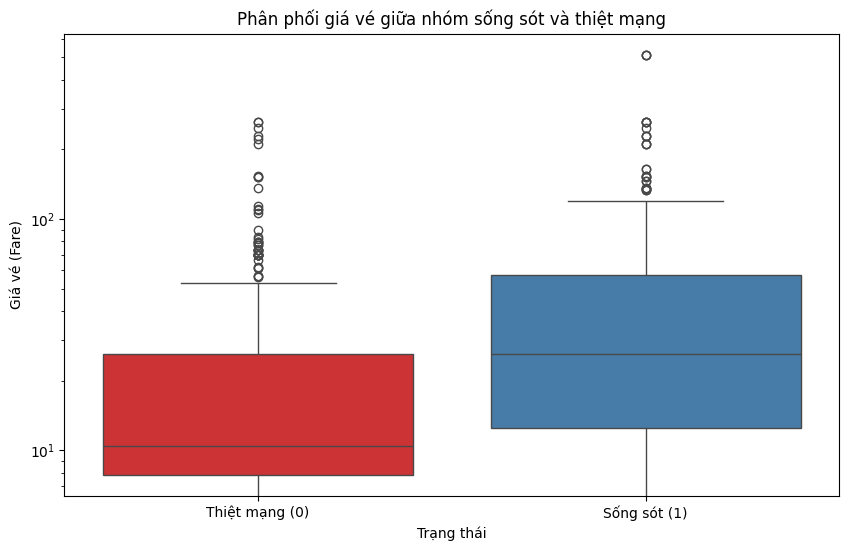

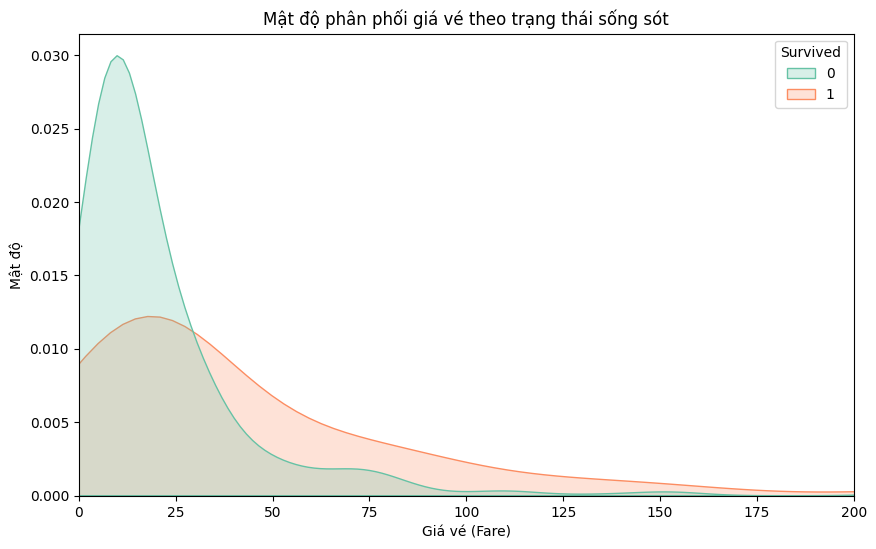

In [45]:
# 16: Trực quan xác suất hành khách sống sót dựa trên thông tin giá vé (Fare)
import matplotlib.pyplot as plt
import seaborn as sns

# Biểu đồ 1: Trực quan phân phối giá vé bằng Box plot (Đã gán hue để fix cảnh báo)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Survived', y='Fare', hue='Survived', palette='Set1', legend=False)
plt.title('Phân phối giá vé giữa nhóm sống sót và thiệt mạng')
plt.xticks([0, 1], ['Thiệt mạng (0)', 'Sống sót (1)'])
plt.xlabel('Trạng thái')
plt.ylabel('Giá vé (Fare)')
plt.yscale('log')
plt.show()

# Biểu đồ 2: Sử dụng Kdeplot với mật độ phân phối giá vé tác động đến sống sót
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Fare', hue='Survived', fill=True, palette='Set2', common_norm=False)
plt.title('Mật độ phân phối giá vé theo trạng thái sống sót')
plt.xlabel('Giá vé (Fare)')
plt.ylabel('Mật độ')
plt.xlim(0, 200)
plt.show()

Nhận xét:
Biểu đồ trực quan hóa mối tương quan giữa giá vé (Fare) và khả năng sinh tồn của hành khách cho thấy các thông tin giá trị sau:

Mối tỷ lệ thuận rõ rệt: Những hành khách mua vé giá cao (đặc biệt là nhóm vé cao cấp) có hộp phân phối (Box plot) nằm ở phân khúc cao hơn hẳn. Xác suất và mật độ sống sót của họ vượt trội so với nhóm mua vé giá rẻ.

Vùng nguy hiểm (Giá vé thấp): Biểu đồ mật độ (Kdeplot) chỉ ra một đỉnh nhọn cực lớn của nhóm thiệt mạng tập trung ở khoảng giá vé rất thấp (từ 0 đến 25 đơn vị tiền tệ). Đây là mức giá vé chủ yếu thuộc về khoang hạng 3.

Thông tin giá trị: Giá vé không đơn thuần là một con số tài chính, mà nó phản ánh trực tiếp vị trí cabin và mức độ ưu tiên tiếp cận xuồng cứu sinh. Hành khách trả nhiều tiền hơn được xếp ở các tầng boong tàu cao hơn, gần với boong cứu hộ hơn, mang lại lợi thế sinh tồn cốt lõi khi tai nạn xảy ra.

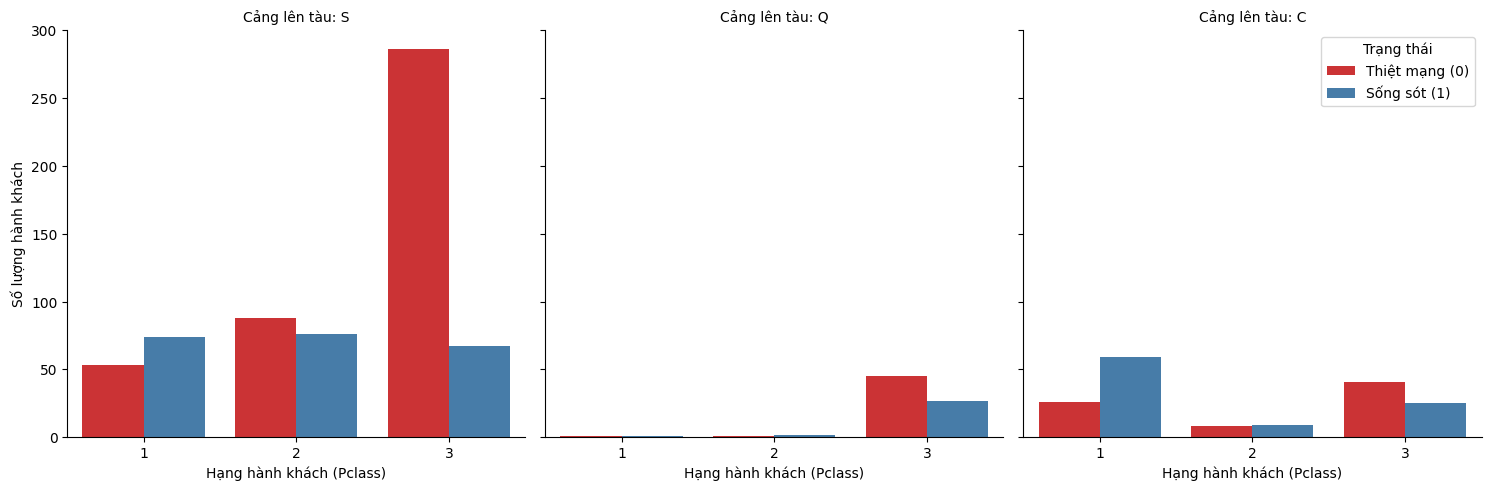

In [42]:
# 17: Trực quan số lượng người sống sót/thiệt mạng theo Pclass và Cảng lên tàu (Embarked)
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ catplot và tắt legend mặc định bằng legend=False để tự định nghĩa lại cho chuẩn
g = sns.catplot(
    data=df,
    x='Pclass',
    hue='Survived',
    col='Embarked',
    kind='count',
    height=5,
    aspect=1,
    palette='Set1',
    legend=False
)

g.set_axis_labels("Hạng hành khách (Pclass)", "Số lượng hành khách")
g.set_titles("Cảng lên tàu: {col_name}")

# Thêm duy nhất một bảng chú thích chuẩn, rõ ràng cho toàn bộ biểu đồ
plt.legend(title='Trạng thái', labels=['Thiệt mạng (0)', 'Sống sót (1)'], loc='upper right')

plt.show()

Nhận xét:
Biểu đồ trực quan đa biến kết hợp giữa Hạng vé (Pclass), Cảng lên tàu (Embarked) và trạng thái sinh tồn (Survived) mang lại những thông tin giá trị sau:

Cảng C (Cherbourg): Đây là nơi duy nhất có tỷ lệ sống sót rất cao, đặc biệt là ở hành khách hạng 1 (Pclass 1). Số người sống sót ở hạng 1 tại cảng này vượt trội so với số người thiệt mạng. Điều này cho thấy phần lớn giới thượng lưu giàu có đã lên tàu từ cảng Cherbourg.

Cảng S (Southampton): Đây là cảng khởi hành chính nên có số lượng hành khách đông nhất ở mọi hạng vé. Tuy nhiên, tỷ lệ thiệt mạng tại cảng này lại cao khủng khiếp, đặc biệt là ở hành khách hạng 3 (Pclass 3). Phần lớn lực lượng lao động, hành khách nghèo mua vé hạng 3 đều lên tàu từ đây và chịu tổn thất nặng nề nhất.

Cảng Q (Queenstown): Hành khách lên tàu tại cảng này hầu như chỉ mua vé hạng 3 (Pclass 3). Số lượng người sống sót ở cảng này rất thấp và số lượng thiệt mạng chiếm phần lớn, phản ánh tình trạng chung của phân khúc vé giá rẻ.

Thông tin giá trị: Cảng lên tàu (Embarked) gián tiếp phản ánh mức độ giàu có và vị thế kinh tế của hành khách tại khu vực đó. Khả năng sống sót không chỉ phụ thuộc vào hạng vé bạn đi, mà còn liên quan đến việc cấu trúc phân bổ hành khách giàu/nghèo phân hóa theo từng cảng cập bến.